In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
data = pd.read_csv("../../data/Test Data.csv")


In [3]:
# Convert 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%y')


In [4]:
data.set_index('Date', inplace=True)

In [5]:
# Group by 'Date' and calculate the average for each column
data = data.groupby('Date').mean()

In [6]:
data

,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
Date,,,,,,,,,,,,,,,
2022-09-01,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848.0,251968.1429,393.651786,32890183.17,37.050402,4142157.11
2022-09-02,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313.0,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2022-09-03,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565.0,246798.6027,388.062500,33383868.74,36.708884,4281017.27
2022-09-04,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303.0,257327.6563,387.245536,32606986.82,36.628527,4140106.66
2022-09-05,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314.0,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-28,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629.0,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
2023-08-29,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688.0,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
2023-08-30,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111.0,133872.1556,362.741936,65854384.38,40.078159,7464569.80


In [7]:
# Selecting relevant columns for the analysis
columns_of_interest = [
    'User Count Average', 'Data Volume DL', 'UL_TRAFFIC_MB', 
    'Average User Throughput DL', 'Average User Throughput UL', 
    'CSSR', 'DL_LATENCY', 'DL_PACK_LOSS_RATE'
]

# Extract the relevant data
data_filtered = data[columns_of_interest]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_filtered)

# Creating a DataFrame for the scaled data
scaled_data_df = pd.DataFrame(scaled_data, columns=columns_of_interest)

In [8]:
# Prepare input and output data
X = scaled_data_df.drop(['Average User Throughput DL', 'Average User Throughput UL'], axis=1).values
y_dl = scaled_data_df['Average User Throughput DL'].values
y_ul = scaled_data_df['Average User Throughput UL'].values

# Reshape the input data to be 3D [samples, timesteps, features] for LSTM
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Split the data into training and testing sets
X_train, X_test, y_dl_train, y_dl_test, y_ul_train, y_ul_test = train_test_split(X, y_dl, y_ul, test_size=0.2, random_state=42)

In [9]:
# Build the LSTM model for Downlink (DL) Throughput prediction
model_dl = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(50),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_dl.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history_dl = model_dl.fit(X_train, y_dl_train, epochs=50, batch_size=16, validation_data=(X_test, y_dl_test), verbose=1)

# Build the LSTM model for Uplink (UL) Throughput prediction
model_ul = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(50),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_ul.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history_ul = model_ul.fit(X_train, y_ul_train, epochs=50, batch_size=16, validation_data=(X_test, y_ul_test), verbose=1)

Epoch 1/50
19/19 [==============================] - 6s 78ms/step - loss: 0.1740 - val_loss: 0.0991
Epoch 2/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0640 - val_loss: 0.0417
Epoch 3/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0384 - val_loss: 0.0343
Epoch 4/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0306 - val_loss: 0.0270
Epoch 5/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0238 - val_loss: 0.0203
Epoch 6/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0176 - val_loss: 0.0144
Epoch 7/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0126 - val_loss: 0.0122
Epoch 8/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0102 - val_loss: 0.0116
Epoch 9/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0098 - val_loss: 0.0123
Epoch 10/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0095 - val_loss: 0.0112
Epoch 11/50
19/19 

Epoch 34/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0225 - val_loss: 0.0199
Epoch 35/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0220 - val_loss: 0.0201
Epoch 36/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0218 - val_loss: 0.0186
Epoch 37/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0226 - val_loss: 0.0187
Epoch 38/50
19/19 [==============================] - 0s 5ms/step - loss: 0.0221 - val_loss: 0.0186
Epoch 39/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0216 - val_loss: 0.0184
Epoch 40/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0210 - val_loss: 0.0203
Epoch 41/50
19/19 [==============================] - 0s 7ms/step - loss: 0.0206 - val_loss: 0.0179
Epoch 42/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0206 - val_loss: 0.0193
Epoch 43/50
19/19 [==============================] - 0s 6ms/step - loss: 0.0205 - val_loss: 0.0198
Epoch 44/5

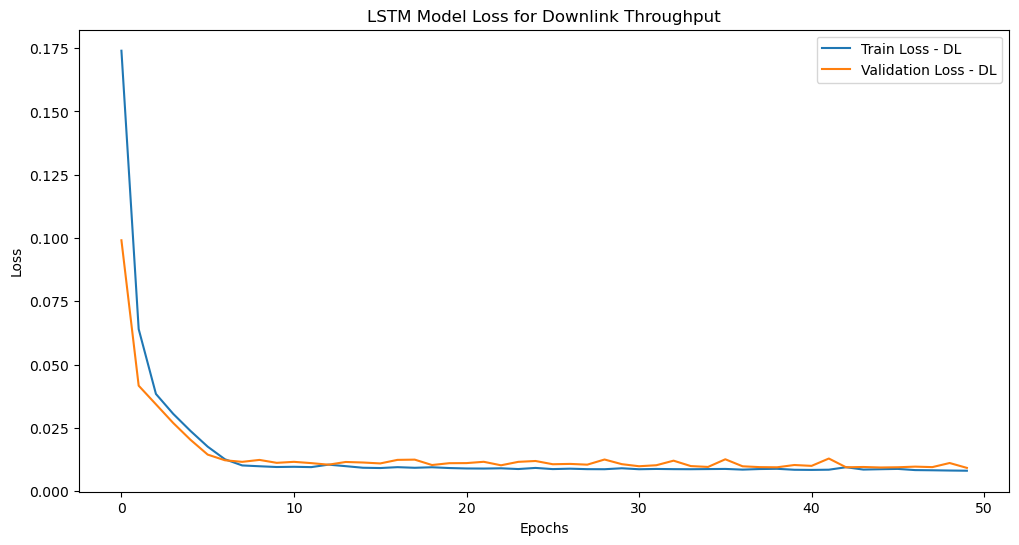

In [10]:
# Plot the training and validation loss for DL Throughput
plt.figure(figsize=(12, 6))
plt.plot(history_dl.history['loss'], label='Train Loss - DL')
plt.plot(history_dl.history['val_loss'], label='Validation Loss - DL')
plt.title('LSTM Model Loss for Downlink Throughput')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

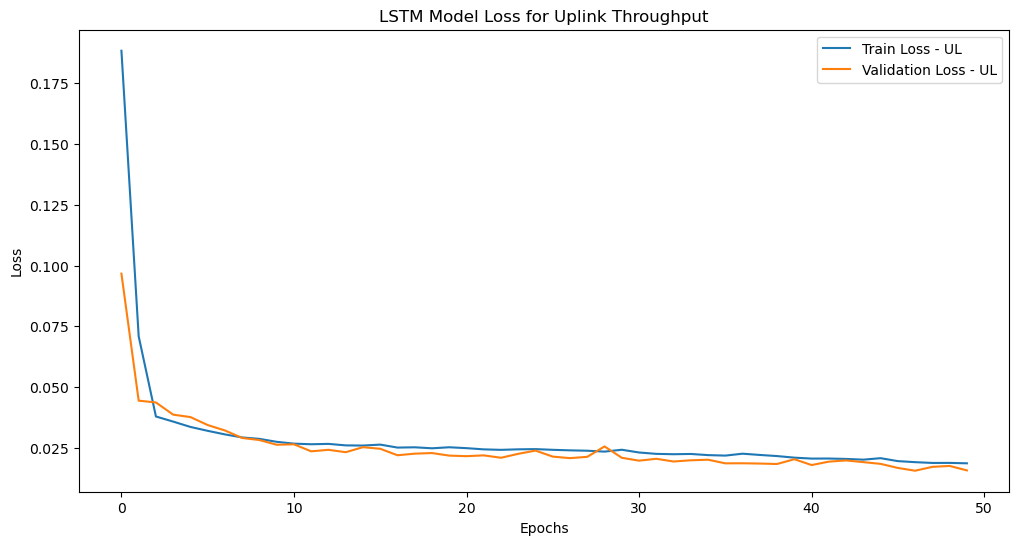

In [11]:
# Plot the training and validation loss for UL Throughput
plt.figure(figsize=(12, 6))
plt.plot(history_ul.history['loss'], label='Train Loss - UL')
plt.plot(history_ul.history['val_loss'], label='Validation Loss - UL')
plt.title('LSTM Model Loss for Uplink Throughput')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
# Make predictions
y_dl_pred = model_dl.predict(X_test)
y_ul_pred = model_ul.predict(X_test)

# Inverse transform the predictions and actual values to get them back to the original scale
y_dl_pred_original = scaler.inverse_transform(np.concatenate((np.zeros((y_dl_pred.shape[0], X.shape[2])), y_dl_pred), axis=1))[:, -1]
y_dl_test_original = scaler.inverse_transform(np.concatenate((np.zeros((y_dl_test.shape[0], X.shape[2])), y_dl_test.reshape(-1,1)), axis=1))[:, -1]

y_ul_pred_original = scaler.inverse_transform(np.concatenate((np.zeros((y_ul_pred.shape[0], X.shape[2])), y_ul_pred), axis=1))[:, -1]
y_ul_test_original = scaler.inverse_transform(np.concatenate((np.zeros((y_ul_test.shape[0], X.shape[2])), y_ul_test.reshape(-1,1)), axis=1))[:, -1]


3/3 [==============================] - 1s 3ms/step


ValueError: operands could not be broadcast together with shapes (74,7) (8,) (74,7) 